# Demonstração Guiada: PostgreSQL/PostGIS no Google Colab

**Objetivo:** mostrar, de maneira panorâmica, como um banco geográfico pode ser
consultado com SQL e utilizado pelo Python para gerar tabelas e mapas.

> Os alunos não precisam memorizar os comandos de instalação e configuração.
> As primeiras etapas podem ser executadas pelo professor.

O banco utilizado contém **saneamento** e geometrias simplificadas.


## Visão geral do fluxo

1. Instalar PostgreSQL, PostGIS e bibliotecas Python;
2. Criar um banco temporário no Colab;
3. Enviar e importar o arquivo `.sql`;
4. Criar uma conexão;
5. Fazer consultas simples;
6. Gerar mapas;
7. Executar uma consulta espacial.


## 1. Preparar o ambiente — professor executa

Esta célula instala os programas necessários na máquina temporária do Colab.
Quando a sessão for reiniciada, esta etapa precisará ser executada novamente.


In [1]:
%%capture
!sudo apt-get update -qq
!sudo apt-get install -y postgresql postgresql-contrib postgis
!pip install -q pandas geopandas sqlalchemy psycopg2-binary matplotlib folium mapclassify shapely geoalchemy2


In [ ]:
!sudo service postgresql start
print("PostgreSQL iniciado.")


## 2. Criar o banco temporário — professor executa

A senha abaixo é apenas didática e vale somente dentro da sessão temporária.
Não utilize essa senha em um servidor real.


In [ ]:
import subprocess

DB_NAME = "geoprocessamento_demo"
DB_USER = "postgres"
DB_PASSWORD = "123"

comandos = [
    [
        "sudo", "-u", "postgres", "psql", "-c",
        f"ALTER USER postgres WITH PASSWORD '{DB_PASSWORD}';"
    ],
    ["sudo", "-u", "postgres", "dropdb", "--if-exists", DB_NAME],
    ["sudo", "-u", "postgres", "createdb", DB_NAME],
]

for comando in comandos:
    subprocess.run(comando, check=True)

print(f"Banco temporário criado: {DB_NAME}")


## 3. Enviar o banco de teste

Execute a célula e selecione o arquivo:

`Banco_PostGIS_Teste_Manaus.sql`


In [ ]:
# pegar o arquivo do computador
from google.colab import files
from pathlib import Path

enviados = files.upload()

arquivos_sql = [
    nome for nome in enviados
    if nome.lower().endswith(".sql")
]

if not arquivos_sql:
    raise ValueError("Nenhum arquivo .sql foi enviado.")

arquivo_sql = Path("/content") / arquivos_sql[0]
print("Arquivo selecionado:", arquivo_sql)


In [ ]:
# Puxar o arquivo diretamente do git
!wget -O /content/saneamento_restricoes_vs14.sql https://raw.githubusercontent.com/sclaudiobr/geodb/main/saneamento_restricoes_vs14.sql

from pathlib import Path
arquivo_sql = Path("/content") / "saneamento_restricoes_vs14.sql"
print("Arquivo baixado:", arquivo_sql)

## 4. Importar o arquivo SQL — professor executa


In [ ]:
resultado = subprocess.run(
    [
        "sudo", "-u", "postgres",
        "psql",
        "--set", "ON_ERROR_STOP=on",
        "--dbname", "postgres",  # Conecta no banco neutro aqui
        "--file", str(arquivo_sql)
    ],
    text=True,
    capture_output=True
)

if resultado.returncode != 0:
    print("--- STDOUT ---")
    print(resultado.stdout)
    print("--- STDERR ---")
    print(resultado.stderr)
    raise RuntimeError("Falha ao importar o banco.")

print("Banco importado com sucesso.")
if resultado.stdout:
    print(resultado.stdout[-1500:])


## 5. Criar a conexão do Python com o banco

A variável `engine` representa a conexão que será utilizada pelo Pandas e
pelo GeoPandas.


In [ ]:
from urllib.parse import quote_plus

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import subprocess

DATABASE_URL = (
    f"postgresql+psycopg2://"
    f"{DB_USER}:{quote_plus(DB_PASSWORD)}@"
    f"localhost:5432/{DB_NAME}"
)

engine = create_engine(DATABASE_URL, pool_pre_ping=True)
print("Conexão criada.")

# ... [Seu código intermediário que usa o engine] ...

# ANTES DE RODAR O SUBPROCESS: Fecha todas as conexões e limpa o pool
engine.dispose()
print("Pool de conexões limpo. O banco foi liberado.")

# Agora o subprocess consegue rodar o DROP DATABASE sem ser bloqueado
resultado = subprocess.run(
    [
        "sudo", "-u", "postgres",
        "psql",
        "--set", "ON_ERROR_STOP=on",
        "--dbname", "postgres", # Conectando no banco neutro aqui no psql
        "--file", str(arquivo_sql)
    ],
    text=True,
    capture_output=True
)


## 6. Testar PostgreSQL e PostGIS


In [ ]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import subprocess

# 1. Defina a conexão apontando para o banco padrão 'postgres'
# Isso evita o erro de "banco já existe" ou "banco em uso" no passo de remoção
DATABASE_URL = (
    f"postgresql+psycopg2://"
    f"{DB_USER}:{quote_plus(DB_PASSWORD)}@"
    f"localhost:5432/Aula9"
)

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True
)

print("Conexão criada com o banco administrativo.")

# 2. Executa a checagem de versões
with engine.connect() as conexao:
    versao_pg = conexao.execute(
        text("SELECT version();")
    ).scalar()

    # Nota: PostGIS geralmente é instalado por banco.
    # Se falhar aqui por não estar no banco 'postgres', comente esta linha.
    try:
        versao_postgis = conexao.execute(
            text("SELECT PostGIS_Full_Version();")
        ).scalar()
    except Exception:
        versao_postgis = "PostGIS não instalado no banco padrão 'postgres'."

print("PostgreSQL:")
print(versao_pg)
print("\nPostGIS:")
print(versao_postgis)

# 3. Fecha explicitamente todas as conexões abertas do pool
engine.dispose()
print("\nPool de conexões liberado.")

# 4. Executa a importação do arquivo estrutural via psql
resultado = subprocess.run(
    [
        "sudo", "-u", "postgres",
        "psql",
        "--set", "ON_ERROR_STOP=on",
        "--dbname", "postgres",  # Mantém a conexão no banco neutro
        "--file", str(arquivo_sql)
    ],
    text=True,
    capture_output=True
)

if resultado.returncode != 0:
    print("\n--- ERRO NA IMPORTAÇÃO ---")
    print(resultado.stderr)
    raise RuntimeError("Falha ao importar o banco.")

print("\nBanco importado com sucesso.")


## 7. Importar camadas de dados geoespaciais

In [ ]:
# URLs para download via wget
urls_wget = [
    "https://raw.githubusercontent.com/sclaudiobr/geodb/main/ocorrencia.geojson",
    "https://raw.githubusercontent.com/sclaudiobr/geodb/main/trecho.geojson",
    "https://raw.githubusercontent.com/sclaudiobr/geodb/main/bairro.geojson"
]

# Baixar todos com wget
for url in urls_wget:
    nome = url.split('/')[-1]
    !wget -O /content/$nome $url

print("\n✅ Downloads concluídos!")

# Listar os arquivos baixados
from pathlib import Path
arquivos = list(Path("/content").glob("*.geojson"))
print(f"📁 Arquivos baixados: {len(arquivos)}")
for arq in arquivos:
    print(f"   {arq.name}: {arq.stat().st_size / 1024:.2f} KB")

In [ ]:
import geopandas as gpd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

# 1. Conexão com o banco final 'Aula9'
DATABASE_URL_AULA9 = (
    f"postgresql+psycopg2://"
    f"{DB_USER}:{quote_plus(DB_PASSWORD)}@"
    f"localhost:5432/Aula9"
)

engine_aula9 = create_engine(DATABASE_URL_AULA9)

caminho_geojson = "/content/trecho.geojson"
nome_da_tabela = "trecho"

# 2. DROP FORÇADO: Remove a tabela e qualquer dependência (Views, Triggers, Constraints)
print(f"Executando DROP forçado na tabela '{nome_da_tabela}' se ela existir...")
with engine_aula9.connect() as conexao:
    # O CASCADE força a exclusão mesmo se houver objetos vinculados à tabela
    conexao.execute(text(f'DROP TABLE IF EXISTS "{nome_da_tabela}" CASCADE;'))
    # Garante a gravação imediata da exclusão no banco de dados
    conexao.commit()

# 3. Leitura e importação do GeoJSON
print(f"Lendo o arquivo GeoJSON: {caminho_geojson}...")
gdf = gpd.read_file(caminho_geojson)

print(f"Enviando {len(gdf)} registros para a nova tabela '{nome_da_tabela}'...")

# 4. Salva os novos dados geográficos
# Usamos 'append' aqui porque o DROP manual já limpou o espaço de forma forçada
# 4. Salva os novos dados geográficos (a coluna geométrica é detectada automaticamente)
gdf.to_postgis(
    name=nome_da_tabela,
    con=engine_aula9,
    if_exists="append",

    index=False
)

print("Camada substituída com sucesso via DROP forçado!")
engine_aula9.dispose()


##8. Listar as tabelas

Aqui o Python pergunta ao banco quais tabelas estão disponíveis.


In [ ]:
consulta_tabelas = """
SELECT
    table_schema AS esquema,
    table_name AS tabela,
    table_type AS tipo
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tabelas = pd.read_sql_query(consulta_tabelas, engine)
tabelas


## 9. Primeira consulta SQL

- `SELECT`: escolhe as colunas;
- `FROM`: indica a tabela;
- `ORDER BY`: organiza o resultado;
- `LIMIT`: limita a quantidade de registros.


In [ ]:
consulta = """
SELECT
    nome,pop_2010,pop_2018,area_m2
FROM bairro
ORDER BY nome DESC
LIMIT 5;
"""

pd.read_sql_query(consulta, engine)

In [ ]:
consulta = """
SELECT
    id_trecho,material,extensao
FROM trecho
ORDER BY id_trecho DESC
LIMIT 5;
"""
pd.read_sql_query(consulta, engine)

In [ ]:
consulta = """
SELECT
    id_ocorrencia,tipo,data
FROM ocorrencia
ORDER BY id_ocorrencia DESC
LIMIT 5;
"""
pd.read_sql_query(consulta, engine)

## 10. Pequena interação: alterar um filtro

Troque o valor de `zona_escolhida` e execute novamente.

Opções: `Sul`, `Centro-Sul`, `Norte` e `Oeste`.


In [ ]:
bairro_escolhido = "Centro"

consulta_bairro = text("""
SELECT
    nome,
    area_m2,
    pop_2010
FROM bairro
WHERE nome = :id_trecho
ORDER BY nome DESC;
""")

pd.read_sql_query(
    consulta_bairro,
    engine,
    params={"id_trecho": bairro_escolhido}  # Changed parameter key
)


In [ ]:
# Get complete table structure
query = """
SELECT
    column_name,
    data_type,
    udt_name
FROM information_schema.columns
WHERE table_name = 'bairro'
ORDER BY ordinal_position;
"""

df_columns = pd.read_sql(query, engine)
print(df_columns.to_string())

## 10. Carregar geometrias com GeoPandas

O GeoPandas recebe a coluna `geom` e transforma o resultado em um
`GeoDataFrame`.


In [56]:
bairro_escolhido = "Centro"

consulta_bairros = f"""
SELECT
    id_bairro,
    nome,
    pop_2018,
    area_m2,
    geometry
FROM bairro
WHERE nome = '{bairro_escolhido}'  -- Filter for specific bairro
ORDER BY id_bairro;
"""

bairros = gpd.read_postgis(
    consulta_bairros,
    con=engine,
    geom_col="geometry",
    params={"bairro": bairro_escolhido}
)

In [59]:
from sqlalchemy import text

bairro_escolhido = "Centro"

consulta_bairros = text("""
SELECT
    id_bairro,
    nome,
    pop_2018,
    area_m2,
    -- Replace with your actual geometry column name
    geometry
FROM bairro
WHERE nome ILIKE :bairro  -- ILIKE is case-insensitive in PostgreSQL
ORDER BY id_bairro;
""")

bairros = gpd.read_postgis(
    consulta_bairros,
    con=engine,
    geom_col="geometry",
    params={"bairro": bairro_escolhido}
)

print(f"Records found: {len(bairros)}")

Records found: 1


## 11. Gerar um mapa temático

A população estimada será usada para diferenciar os polígonos.
Os números e limites são fictícios.


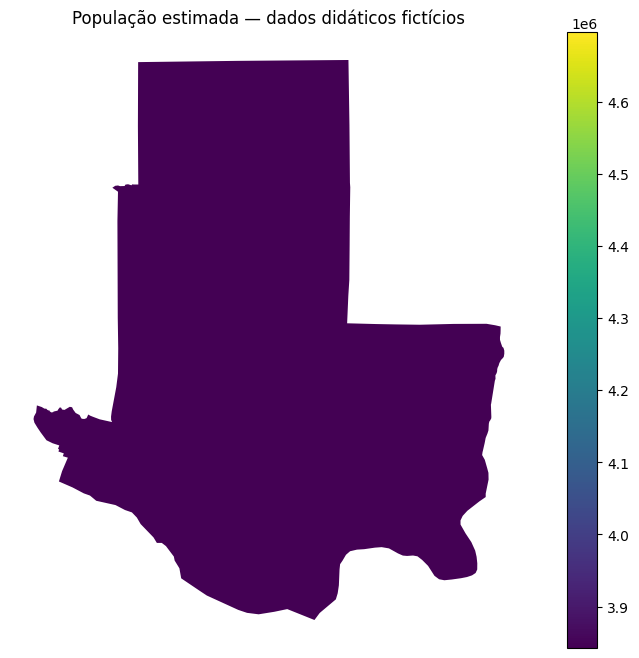

In [61]:
ax = bairros.plot(
    column="area_m2",
    legend=True,
    figsize=(10, 8)
)

ax.set_title("População estimada — dados didáticos fictícios")
ax.set_axis_off()
plt.show()


## 12. Visualizar pontos de interesse


In [ ]:
ocorrencias = gpd.read_postgis(
    """
    SELECT
        id_ocorrencia,
        tipo,
        data,
        geometry
    FROM ocorrencia
    ORDER BY id_ocorrencia;
    """,
    con=engine,
    geom_col="geometry"
)

ocorrencias.head()


In [ ]:
ax = bairros.plot(
    figsize=(10, 8),
    alpha=0.35
)

ocorrencias.plot(
    ax=ax,
    markersize=45
)

ax.set_title("Bairros e ocorrencias fictícios")
ax.set_axis_off()
plt.show()


## 13. Consulta espacial: ocorrencias dentro de cada bairro

`ST_Contains` verifica se um ponto está dentro de um polígono.


In [72]:
consulta_espacial = """
SELECT
    b.nome AS bairro,
    COUNT(*) AS ocorrencia  -- Usa * em vez de e.id
FROM bairro AS b
LEFT JOIN ocorrencia AS e
    ON ST_Contains(b.geometry, e.geometry)
GROUP BY b.id_bairro, b.nome
ORDER BY ocorrencia DESC, b.nome;
"""

resultado = pd.read_sql_query(consulta_espacial, engine)
print(resultado)

                     bairro  ocorrencia
0                    CENTRO           5
1              ADRIANÓPOLIS           1
2                 APARECIDA           1
3  NOSSA SENHORA DAS GRACAS           1
4       PRAÇA 14 DE JANEIRO           1
5         PRESIDENTE VARGAS           1
6               SÃO GERALDO           1


## 14. Consulta espacial por distância

A consulta procura ocorrencias em um raio definido a partir de um ponto.
O aluno pode alterar somente o valor de `raio_m`.


In [ ]:
longitude_referencia = -60.0217
latitude_referencia = -3.1190
raio_km = 5

consulta_distancia = text("""
SELECT
    id_ocorrencia,
    tipo,
    ROUND(
        ST_Distance(
            geometry::geography,
            ST_SetSRID(
                ST_MakePoint(:longitude, :latitude),
                4326
            )::geography
        )::numeric,
        2
    ) AS distancia_km
FROM ocorrencia
WHERE ST_DWithin(
    geometry::geography,
    ST_SetSRID(
        ST_MakePoint(:longitude, :latitude),
        4326
    )::geography,
    :raio_metros
)
ORDER BY distancia_km;
""")

resultado_distancia = pd.read_sql_query(
    consulta_distancia,
    engine,
    params={
        "longitude": longitude_referencia,
        "latitude": latitude_referencia,
        "raio_metros": raio_km * 1000
    }
)

resultado_distancia


In [82]:
trechos = gpd.read_postgis(
    """
    SELECT
        id_trecho,
        material,
        geometry
    FROM trecho
    ORDER BY id_trecho;
    """,
    con=engine,
    geom_col="geometry"
)

trechos.head()

,id_trecho,material,geometry
0,32,MPU,"LINESTRING (-60.01771 -3.12321, -60.02044 -3.1..."
1,34,PVA,"LINESTRING (-60.02125 -3.1204, -60.01661 -3.12..."
2,35,PVC,"LINESTRING (-60.02634 -3.11105, -60.02428 -3.1..."
3,36,CIM,"LINESTRING (-60.02633 -3.11752, -60.01683 -3.1..."
4,37,MAG,"LINESTRING (-60.02263 -3.12596, -60.02072 -3.1..."


## 15. Mapa interativo com Folium


In [ ]:
bairros_4326 = bairros.to_crs(epsg=4326)
equipamentos_4326 = ocorrencias.to_crs(epsg=4326)
trechos_4326  = trechos.to_crs(epsg=4326)

mapa = folium.Map(
    location=[-3.09, -60.03],
    zoom_start=11,
    control_scale=True
)

folium.GeoJson(
    bairros_4326.to_json(),
    name="Bairros",
    tooltip=folium.GeoJsonTooltip(
        fields=["nome", "pop_2018"],
        aliases=["Bairro:", "pop2018:"]
    )
).add_to(mapa)

folium.GeoJson(
    trechos_4326.to_json(),
    name="Trechos",
    tooltip=folium.GeoJsonTooltip(
        fields=["id_trecho", "material"],
        aliases=["Bairro:", "pop2018:"]
    )
).add_to(mapa)

for _, registro in equipamentos_4326.iterrows():
    folium.Marker(
        location=[
            registro.geometry.y,
            registro.geometry.x
        ],
        tooltip=registro["id_ocorrencia"],
        popup=(
            f"<b>{registro['id_ocorrencia']}</b><br>"
            f"Categoria: {registro['tipo']}<br>"
            f"Capacidade: {registro['data']}"
        )
    ).add_to(mapa)

folium.LayerControl().add_to(mapa)
mapa


## 16. Atividade rápida de interpretação

1. Qual tabela guarda os polígonos?
2. Qual tabela guarda os pontos?
3. O que mudou quando a zona foi alterada?
4. Qual bairro possui mais equipamentos na demonstração?
5. O que acontece ao aumentar ou diminuir `raio_km`?
6. Qual é a função da coluna `geom`?
7. Qual foi o papel do SQL?
8. Qual foi o papel do Python?

**Mensagem principal:** o banco armazena e consulta; o Python organiza,
analisa e apresenta; o PostGIS entende as geometrias.


## Observação final

O ambiente e o banco criados no Colab são temporários. Caso a sessão seja
reiniciada, execute novamente as etapas de preparação e importação.
